In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.7 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
import cv2
import os

In [ ]:

model = tf.keras.models.load_model('model.h5')

In [ ]:

# Specify the image dimensions expected by the model
IMG_HEIGHT = 128
IMG_WIDTH = 128

In [ ]:

# Class names (update based on your training data classes)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

In [ ]:

# Function to process a DICOM file
def preprocess_dicom(dcm_path):
    """Loads and preprocesses a DICOM file."""
    # Load the DICOM file
    dicom = pydicom.dcmread(dcm_path)

    # Apply VOI LUT if available (handles different modalities correctly)
    data = apply_voi_lut(dicom.pixel_array, dicom)

    # Normalize the pixel values to [0, 255]
    data = (data - np.min(data)) / (np.max(data) - np.min(data)) * 255.0
    data = data.astype(np.uint8)

    # Resize to the required input size of the model
    resized_image = cv2.resize(data, (IMG_WIDTH, IMG_HEIGHT))

    # If grayscale, expand dimensions to match the 3-channel input shape of the model
    if len(resized_image.shape) == 2:
        resized_image = np.stack([resized_image] * 3, axis=-1)

    # Normalize the image to [0, 1] range for the model
    resized_image = resized_image / 255.0

    return resized_image

In [ ]:

# Function to make predictions on a DICOM file
def predict_dicom(dcm_path):
    """Makes predictions on a single DICOM file."""
    # Preprocess the DICOM file
    preprocessed_image = preprocess_dicom(dcm_path)

    # Add batch dimension and make a prediction
    image_batch = np.expand_dims(preprocessed_image, axis=0)
    predictions = model.predict(image_batch)

    # Calculate the class with the highest confidence score
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]

    return class_names[predicted_class], confidence

In [ ]:
# Single file input
file_path = input("Enter the path of the DICOM file: ")

Enter the path of the DICOM file: /content/WhatsApp-Image-2024-12-14-at-105.dcm


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
File: /content/WhatsApp-Image-2024-12-14-at-105.dcm
Predicted Class: MildDemented
Confidence: 0.90



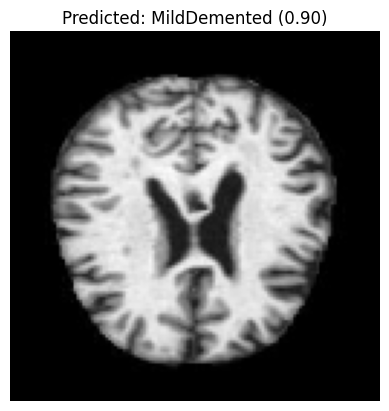

In [ ]:
if os.path.isfile(file_path) and file_path.endswith('.dcm'):
    predicted_class, confidence = predict_dicom(file_path)
    print(f"File: {file_path}\nPredicted Class: {predicted_class}\nConfidence: {confidence:.2f}\n")

    # Optionally, display the image and prediction
    preprocessed_image = preprocess_dicom(file_path)
    plt.imshow(preprocessed_image)
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f})")
    plt.axis("off")
    plt.show()
else:
    print("Invalid file path or file type. Please provide a valid DICOM file.")